In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import geopandas as gpd
import os
from glob import glob

import xarray as xr
import rioxarray as rxr
import rasterio

import warnings
warnings.filterwarnings('ignore')

In [2]:
# List available cities in mnt/
cities = [d for d in os.listdir('mnt') if os.path.isdir(f'mnt/{d}') and d.startswith('20')]
print("Available cities:")
for i, city in enumerate(sorted(cities), 1):
    print(f"{i}. {city}")


Available cities:
1. 2025-02-tunisia-tunis
2. 2025-10-indonesia-sofifi
3. 2025-10-senegal-dakar
4. 2025-10-senegal-dakar-old
5. 2025-10-senegal-diourbel
6. 2025-10-senegal-matam
7. 2025-10-senegal-matam-old
8. 2025-10-senegal-tambacounda
9. 2025-11-mauritania-nouakchott
10. 2025-11-mauritania-nouakchott-old
11. 2025-11-senegal-dagana
12. 2025-11-senegal-kolda
13. 2025-11-senegal-thies


In [3]:
# Select city
city_dir = '2025-11-mauritania-nouakchott'
cityname  = city_dir.split('-')[-1]  # Remove year prefix
data_dir = os.path.join('mnt', city_dir, '02-process-output', 'spatial')
temporal_dir = os.path.join('mnt', city_dir, '02-process-output', 'temporal')
user_dir = os.path.join('mnt', city_dir, '01-user-input')


files = glob(data_dir  +   "/*")
t_files = glob(temporal_dir  +   "/*")

print(f"\nSelected: {city_dir}. data_dir: {data_dir}")


Selected: 2025-11-mauritania-nouakchott. data_dir: mnt/2025-11-mauritania-nouakchott/02-process-output/spatial


In [4]:
aoi = gpd.read_file(glob(user_dir+ '/AOI/*.shp')[0]).to_crs("EPSG:4326")
# wards = gpd.read_file(glob(user_dir+ '/wards/*.shp')[0]).to_crs("EPSG:4326")

ghs_tifs = [f for f in t_files if 'ghs_built' in f]
ghs_tifs

['mnt/2025-11-mauritania-nouakchott/02-process-output/temporal/nouakchott_ghs_built_2015.tif',
 'mnt/2025-11-mauritania-nouakchott/02-process-output/temporal/nouakchott_ghs_built_2000.tif',
 'mnt/2025-11-mauritania-nouakchott/02-process-output/temporal/nouakchott_ghs_built_2010.tif',
 'mnt/2025-11-mauritania-nouakchott/02-process-output/temporal/nouakchott_ghs_built_2005.tif',
 'mnt/2025-11-mauritania-nouakchott/02-process-output/temporal/nouakchott_ghs_built_1975.tif',
 'mnt/2025-11-mauritania-nouakchott/02-process-output/temporal/nouakchott_ghs_built_1990.tif',
 'mnt/2025-11-mauritania-nouakchott/02-process-output/temporal/nouakchott_ghs_built_1985.tif',
 'mnt/2025-11-mauritania-nouakchott/02-process-output/temporal/nouakchott_ghs_built_1995.tif',
 'mnt/2025-11-mauritania-nouakchott/02-process-output/temporal/nouakchott_ghs_built_1980.tif',
 'mnt/2025-11-mauritania-nouakchott/02-process-output/temporal/nouakchott_ghs_built_2020.tif',
 'mnt/2025-11-mauritania-nouakchott/02-process-out

In [5]:
osm_keys = {
    'residential': {
        'building': ['residential', 'apartments', 'house', 'detached', 'terrace', 'dormitory'],
        'landuse': ['residential']
    },
    'commercial': {
        'shop': True,  # gets all shop types
        'amenity': ['restaurant', 'cafe', 'bar', 'bank', 'marketplace', 'fast_food'],
        'office': True,
        'building': ['commercial', 'retail'],
        'landuse': ['commercial', 'retail'],
        'tourism': ['hotel']
    },
    'industrial': {
        'landuse': ['industrial', 'brownfield', 'quarry'],
        'building': ['industrial', 'warehouse', 'manufacture'],
        'man_made': ['works', 'storage_tank'],
        'craft': True
    }
}

In [6]:
import osmnx as ox

aoi_geom = aoi.geometry.unary_union

osm = {}

for category, tags in osm_keys.items():
    all_features = []
    
    for key, value in tags.items():
        try:
            gdf = ox.features_from_polygon(aoi_geom, tags={key: value})
            gdf['osm_type'] = f"{key}_{value}"
            all_features.append(gdf)
            print(f"Found {len(gdf)} features for {category}: {key}={value}")
        except Exception as e:
            print(f"No data for {category}: {key}={value}")
    
    # Combine all for this category
    if all_features:
        combined = pd.concat(all_features, ignore_index=True)
        # Before calculating centroid
        combined = combined.to_crs('EPSG:3857')  # Web Mercator or use local UTM
        combined['geometry'] = combined.geometry.centroid
        combined = combined.to_crs('EPSG:4326')  # Convert back to lat/lon
        
        # Remove duplicates by location
        combined = combined.drop_duplicates(subset=['geometry'], keep='first')
        
        osm[category] = combined
    else:
        osm[category] = None


Found 4077 features for residential: building=['residential', 'apartments', 'house', 'detached', 'terrace', 'dormitory']
Found 533 features for residential: landuse=['residential']
Found 1233 features for commercial: shop=True
Found 402 features for commercial: amenity=['restaurant', 'cafe', 'bar', 'bank', 'marketplace', 'fast_food']
Found 202 features for commercial: office=True
Found 81 features for commercial: building=['commercial', 'retail']
Found 235 features for commercial: landuse=['commercial', 'retail']
Found 51 features for commercial: tourism=['hotel']
Found 67 features for industrial: landuse=['industrial', 'brownfield', 'quarry']
Found 54 features for industrial: building=['industrial', 'warehouse', 'manufacture']
Found 39 features for industrial: man_made=['works', 'storage_tank']
Found 111 features for industrial: craft=True


In [7]:
for key in osm.keys():
    print(f"{key}: {len(osm[key])} features")

residential: 4610 features
commercial: 2174 features
industrial: 271 features


In [8]:
# Map each item to a color
color_map = {'residential': "blue",
             'retail':  "purple",
             'commercial': "red",
             'office_buildings': "brown",
             'industrial': "orange",
             'warehouses': "khaki",
             'tourism': "green",
             'government': "maroon",
             
             }

In [9]:
# osm_files = [f for f in files if "osm" in f]

# roads = gpd.read_file(glob(data_dir + "/*roads*")[0]).to_crs("EPSG:4326")

In [10]:
# Get major roads
roads = ox.graph_from_polygon(
    aoi_geom, 
    network_type='drive',
    custom_filter='["highway"~"motorway|trunk|primary|secondary"]'
)

# Convert to GeoDataFrame
roads = ox.graph_to_gdfs(roads, nodes=False, edges=True)


/Users/vivaldirinaldi/miniforge3/envs/cityscan/lib/python3.10/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


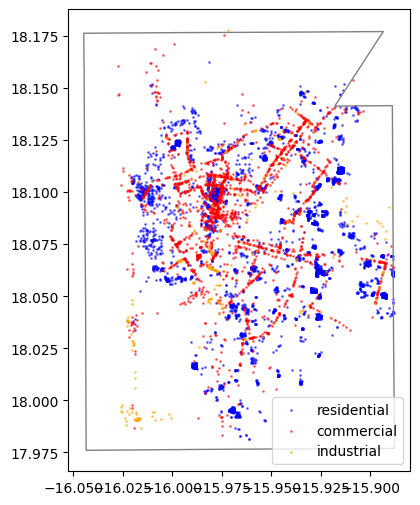

In [11]:
plt.figure(figsize=(10, 6))


aoi.boundary.plot(ax=plt.gca(), color='grey', linewidth=1)
# wards.boundary.plot(ax=plt.gca(), color='darkgrey', linewidth=1)

# roads.plot(ax=plt.gca(), color='black', linewidth=1, alpha=0.7, label='major roads')

for  n, i in enumerate(osm_keys.keys()):

    osm[i].plot(ax=plt.gca(), color=color_map[i], markersize=1, alpha=0.5, label=i)

plt.legend()

# xmin, xmax = -17.535, -17.415
# ymin, ymax = 14.645, 14.77


# xmin, xmax = -17.535, -17.3
# ymin, ymax = 14.645, 14.8

# plt.xlim(xmin, xmax)
# plt.ylim(ymin, ymax )
plt.show()


### GHS

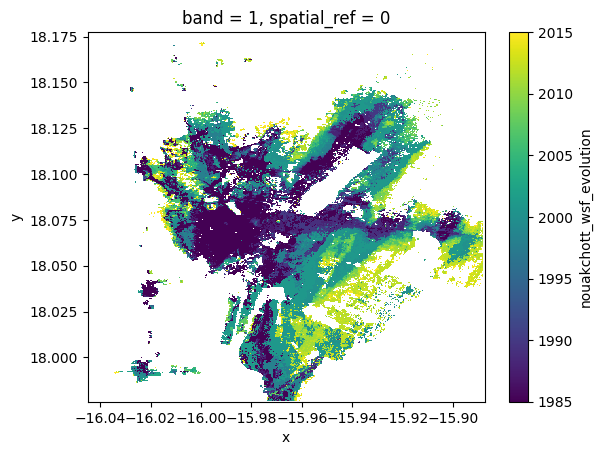

In [12]:
wsf = rxr.open_rasterio(glob(data_dir + "/*wsf-edit.tif")[0])
wsf. plot()

In [13]:
from backend.raster_pro import calculate_raster_area

In [14]:
years = [1975, 1980, 1985, 1990, 1995, 2000, 2005, 2010, 2015, 2020, 2025]

# Step 1: Load and separate residential from non-residential
ghs_builts = {}

for year, built_file in zip(years, sorted(ghs_tifs)):

    r = rxr.open_rasterio(built_file, masked=True).rio.reproject_match(wsf)

    built = r.sel(band=1)
    nres = r.sel(band=2)

    res = built - nres
    res = res.rio.clip(aoi.geometry.values, aoi.crs)
    nres = nres.rio.clip(aoi.geometry.values, aoi.crs)

    ghs_builts[year] = {
        'res': res,
        'nres': nres
    }

    
  

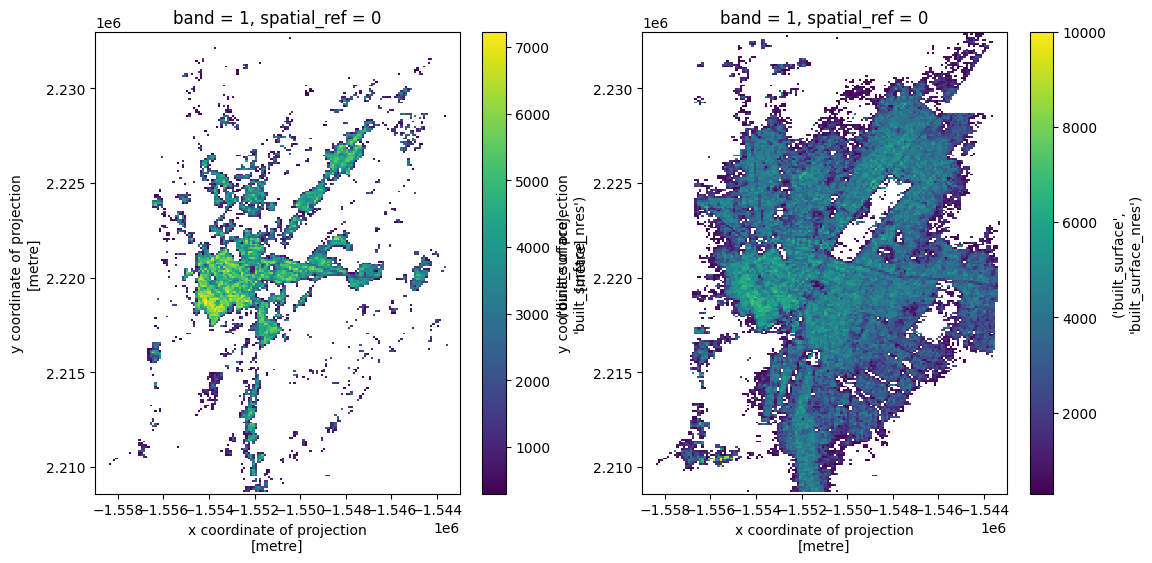

In [15]:
first = rxr.open_rasterio(sorted(ghs_tifs)[0], masked=True).rio.clip(aoi.geometry.values, aoi.crs)

last = rxr.open_rasterio(sorted(ghs_tifs)[-2], masked=True).rio.clip(aoi.geometry.values, aoi.crs)

plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
first.sel(band = 1).where(first.sel(band = 1) > 300).plot()
plt.subplot(1, 3, 2)
last.sel(band = 1).where(last.sel(band = 1) > 300).plot()


In [16]:
res_expansion = None
nres_expansion = None

ar = 1000

for i, year in enumerate(years):
    res = ghs_builts[year]['res']
    nres = ghs_builts[year]['nres']
    
    if res_expansion is None:
        # Initialize with NaN everywhere, then set built pixels to year
        res_expansion = xr.full_like(res, np.nan)
        res_expansion = xr.where(res > ar , year, res_expansion)
    else:
        res_expansion = xr.where((res > ar) & (np.isnan(res_expansion)), year, res_expansion)
    
    # Same for nres
    if nres_expansion is None:
        nres_expansion = xr.full_like(nres, np.nan)
        nres_expansion = xr.where(nres > ar, year, nres_expansion)
    else:
        nres_expansion = xr.where((nres > ar) & (np.isnan(nres_expansion)), year, nres_expansion)

In [17]:
res_expansion = res_expansion.rio.write_crs(first.rio.crs)

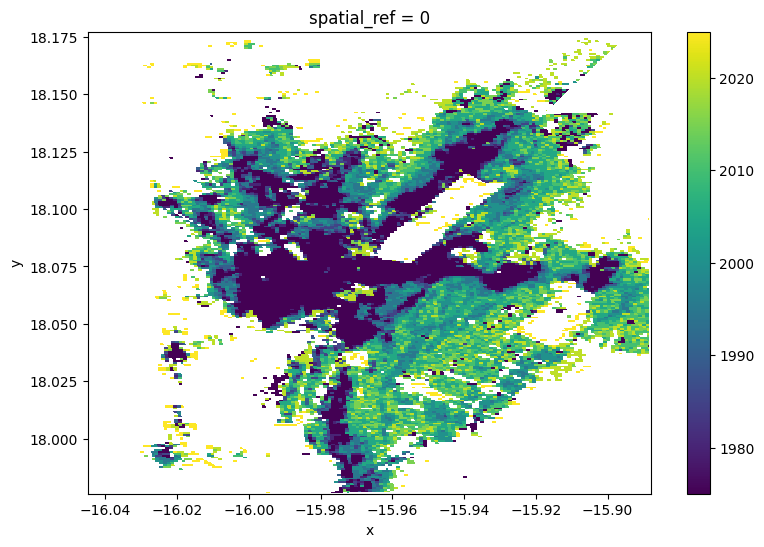

In [18]:
plt.figure(figsize=(20, 6))
plt.subplot(1, 2, 1)
res_expansion.plot(cmap='viridis', vmin=1975, vmax=2025)
# wards.plot(ax=plt.gca())
# plt.subplot(1, 2, 2)
# nres_expansion.plot(cmap='viridis', vmin=1975, vmax=2025)

In [19]:
# .rio.write_crs("EPSG:4326").rio.to_raster(os.path.join(data_dir, f'ghs_res_expansion.tif'))
# nres_expansion.rio.write_crs("EPSG:4326").rio.to_raster(os.path.join(data_dir, f'ghs_nres_expansion.tif'))

### GHS POI

In [20]:
print(osm['residential'].crs)
print(ghs_builts[2020]['res'].rio.crs)

EPSG:4326
EPSG:4326


#### MODELING KDE

In [21]:
target_crs = 'EPSG:32628'

# Reproject built-up
builtup = (ghs_builts[2020]['res'] + ghs_builts[2020]['nres'])
builtup = builtup.rio.reproject(target_crs)
builtup_res = ghs_builts[2020]['res'].rio.reproject(target_crs)
builtup_nres= ghs_builts[2020]['nres'].rio.reproject(target_crs)

# Reproject OSM
osm = {
    'residential': osm['residential'].to_crs(target_crs),
    'commercial': osm['commercial'].to_crs(target_crs),
    'industrial': osm['industrial'].to_crs(target_crs)
}

print(builtup.rio.resolution())

(29.334090817073754, -29.334090817073754)


In [22]:
aoi_utm = aoi.to_crs(builtup.rio.crs)

In [23]:
from rasterio.transform import from_bounds
from scipy.stats import gaussian_kde

# Create 1km resolution grid
bounds = builtup.rio.bounds()
pixel_size = 1000
width = int((bounds[2] - bounds[0]) / pixel_size)
height = int((bounds[3] - bounds[1]) / pixel_size)

# ONE MESHGRID
x = np.linspace(bounds[0], bounds[2], width)
y = np.linspace(bounds[1], bounds[3], height)
xx, yy = np.meshgrid(x, y)
grid_points = np.vstack([xx.ravel(), yy.ravel()])

print(f"Grid: {width} x {height} pixels at {pixel_size}m resolution")

transform = from_bounds(bounds[0], bounds[1], bounds[2], bounds[3], width, height)


Grid: 16 x 22 pixels at 1000m resolution


In [24]:
print(f"Bounds: {bounds}")
print(f"Width: {width}, Height: {height}")

Bounds: (389364.34878088994, 1987774.9672916005, 406114.114637439, 2010098.210403394)
Width: 16, Height: 22


In [25]:
def count_features_per_cell(gdf, width, height, transform):
    if len(gdf) == 0:
        return np.zeros((height, width))
    
    shapes = [(geom, 1) for geom in gdf.geometry if geom is not None]
    
    counts = rasterio.features.rasterize(
        shapes,
        out_shape=(height, width),
        transform=transform,
        fill=0,
        merge_alg=rasterio.enums.MergeAlg.add,
        dtype=np.float32
    )
    
    return counts

In [26]:
from shapely.geometry import Point

# Get which grid points are inside AOI
grid_coords = [Point(x, y) for x, y in zip(grid_points[0], grid_points[1])]
aoi_geom = aoi_utm.geometry.iloc[0]  # Get the actual polygon
inside_aoi = np.array([aoi_geom.contains(pt) for pt in grid_coords])

# Filter grid points to only those inside AOI
grid_points_aoi = grid_points[:, inside_aoi]

In [27]:
probs = {}

# Load LC at native resolution - DON'T resample
lc = rxr.open_rasterio(glob(data_dir + "/*_lc.tif")[0])
lc_utm = lc.rio.reproject(target_crs)

# Get water mask at native resolution (class 80 = water)
water_native = (lc_utm.values[0] == 80)

# Create 1km land mask by checking overlap with water
land_mask = np.ones((height, width), dtype=bool)

# Get LC bounds and resolution
lc_bounds = lc_utm.rio.bounds()
lc_res = abs(lc_utm.rio.resolution()[0])

for i in range(height):
    for j in range(width):
        # 1km cell bounds - i=0 is BOTTOM (south), matching how meshgrid/imshow work after flipud
        cell_xmin = bounds[0] + j * pixel_size
        cell_xmax = cell_xmin + pixel_size
        cell_ymin = bounds[1] + i * pixel_size  # i=0 is bottom (south)
        cell_ymax = cell_ymin + pixel_size
        
        # Find corresponding LC pixels
        col_start = max(0, int((cell_xmin - lc_bounds[0]) / lc_res))
        col_end = min(lc_utm.shape[2], int((cell_xmax - lc_bounds[0]) / lc_res))
        row_end = min(lc_utm.shape[1], int((lc_bounds[3] - cell_ymin) / lc_res))
        row_start = max(0, int((lc_bounds[3] - cell_ymax) / lc_res))
        
        # If majority of cell is water, mask it
        if row_start < row_end and col_start < col_end:
            water_fraction = water_native[row_start:row_end, col_start:col_end].mean()
            if water_fraction > 0.5:
                land_mask[i, j] = False

# Flip to match KDE orientation (north at top)
land_mask = np.flipud(land_mask)

print(f"Land mask: {land_mask.sum()} land pixels, {(~land_mask).sum()} water pixels")

for land_use, gdf in osm.items():
    print(f"Processing {land_use}...")
    
    # FREQUENCY
    probs[f'{land_use}_freq'] = count_features_per_cell(gdf, width, height, transform)
    
    # KDE
    if len(gdf) > 0:
        coords = np.array([[p.x, p.y] for p in gdf.geometry])
        kde = gaussian_kde(coords.T, bw_method=100000/coords.std())
        
        kde_values = kde(grid_points)
        kde_grid = np.flipud(kde_values.reshape(height, width))

        # Apply land mask
        probs[f'{land_use}_kde'] = np.where(land_mask, kde_grid, np.nan)

# NORMALIZE FREQUENCY
total_freq = probs['residential_freq'] + probs['commercial_freq'] + probs['industrial_freq']
total_freq = np.where(total_freq > 0, total_freq, 1.0)

probs['residential_freq'] = probs['residential_freq'] / total_freq
probs['commercial_freq'] = probs['commercial_freq'] / total_freq
probs['industrial_freq'] = probs['industrial_freq'] / total_freq

# NORMALIZE KDE
total_kde = np.nansum([probs['residential_kde'], probs['commercial_kde'], probs['industrial_kde']], axis=0)
total_kde = np.where(total_kde > 0, total_kde, 1.0)

probs['residential_kde'] = probs['residential_kde'] / total_kde
probs['commercial_kde'] = probs['commercial_kde'] / total_kde
probs['industrial_kde'] = probs['industrial_kde'] / total_kde

Land mask: 308 land pixels, 44 water pixels
Processing residential...
Processing commercial...
Processing industrial...


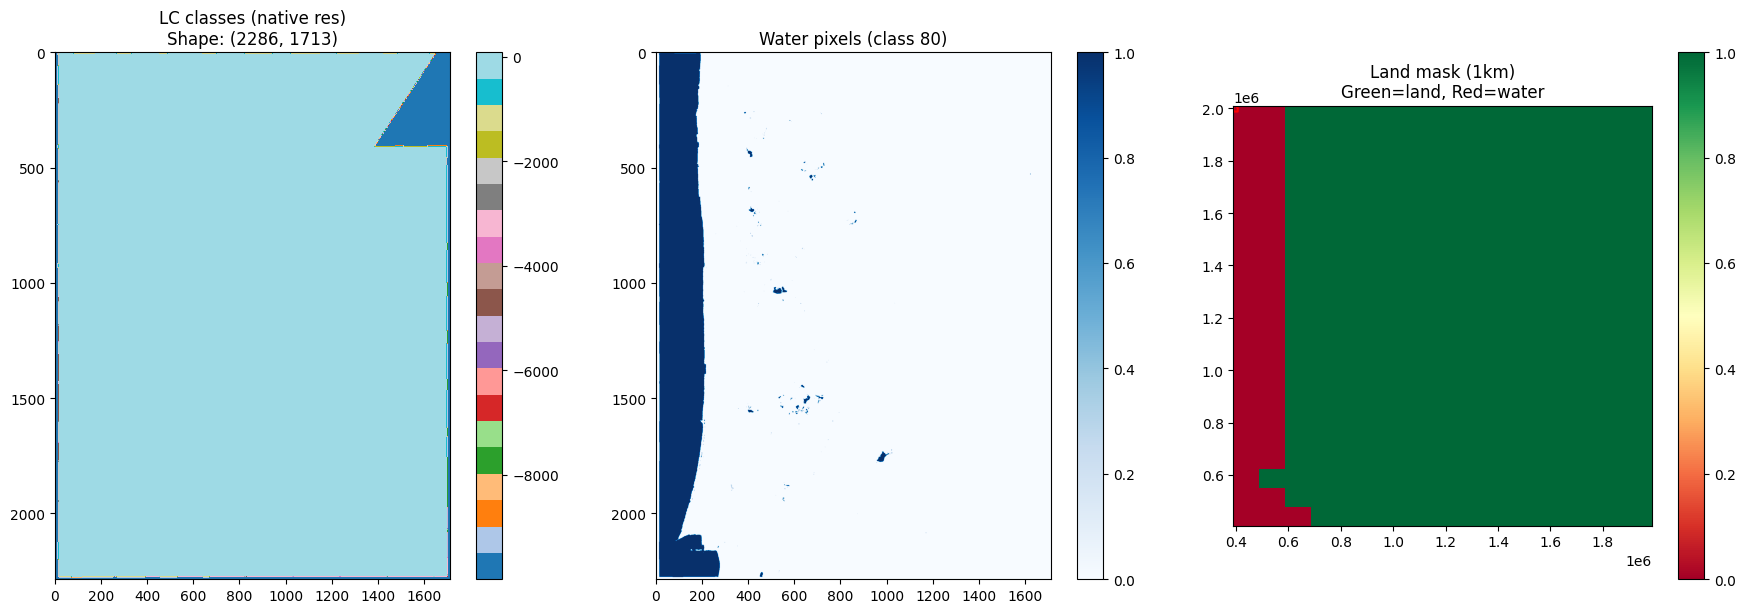

LC unique classes: [-9999    10    20    30    40    50    60    80    90]


In [28]:
# Plot LC and water mask
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. LC classes
ax = axes[0]
im = ax.imshow(lc_utm.values[0], cmap='tab20')
ax.set_title(f'LC classes (native res)\nShape: {lc_utm.shape[1:]}')
plt.colorbar(im, ax=ax)

# 2. Water only (class 80)
ax = axes[1]
im = ax.imshow(water_native, cmap='Blues')
ax.set_title('Water pixels (class 80)')
plt.colorbar(im, ax=ax)

# 3. Land mask at 1km
ax = axes[2]
im = ax.imshow(land_mask, extent=bounds, cmap='RdYlGn')
aoi_utm.boundary.plot(ax=ax, color='red', linewidth=1.5)
ax.set_title(f'Land mask (1km)\nGreen=land, Red=water')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

print(f"LC unique classes: {np.unique(lc_utm.values[0])}")

In [29]:
# fig, ax = plt.subplots(figsize=(10, 10))
# aoi_utm.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2)
# builtup.plot(ax=ax, alpha=0.5)

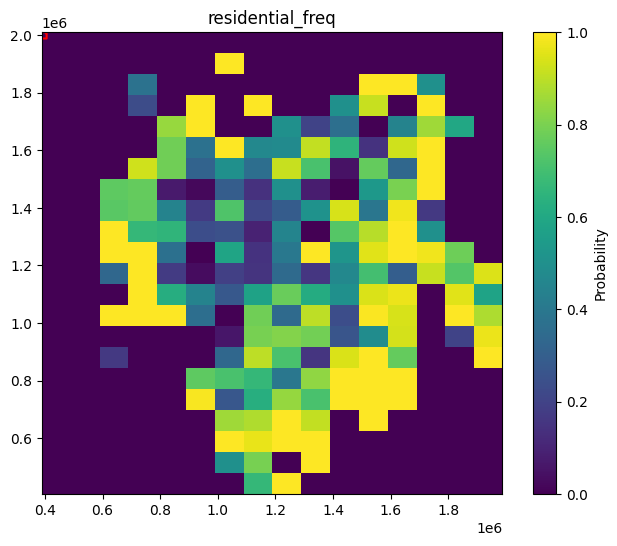

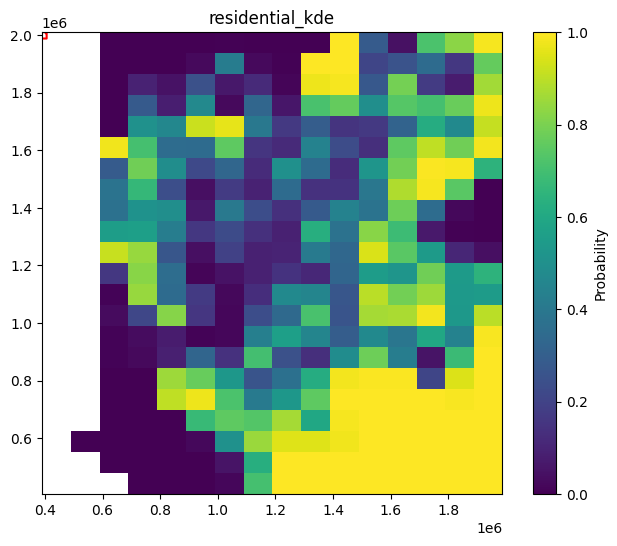

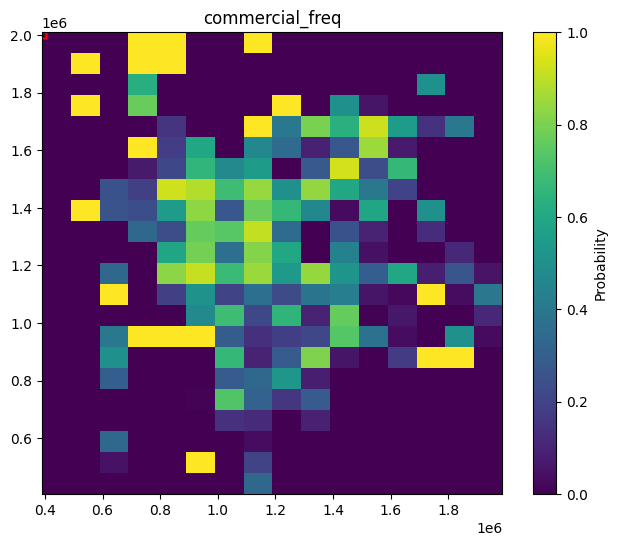

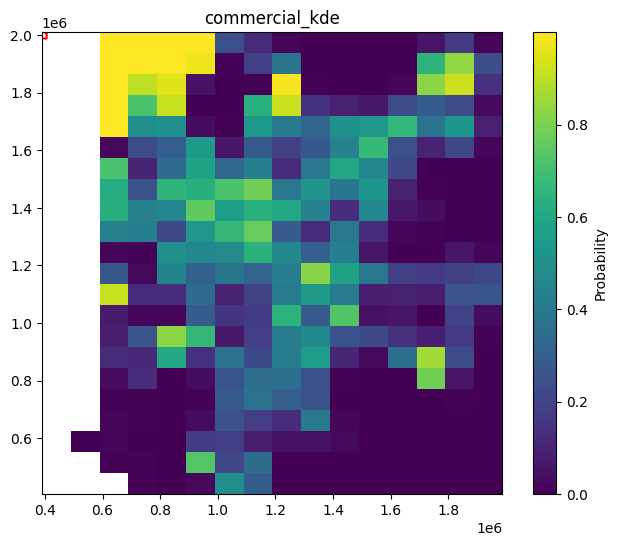

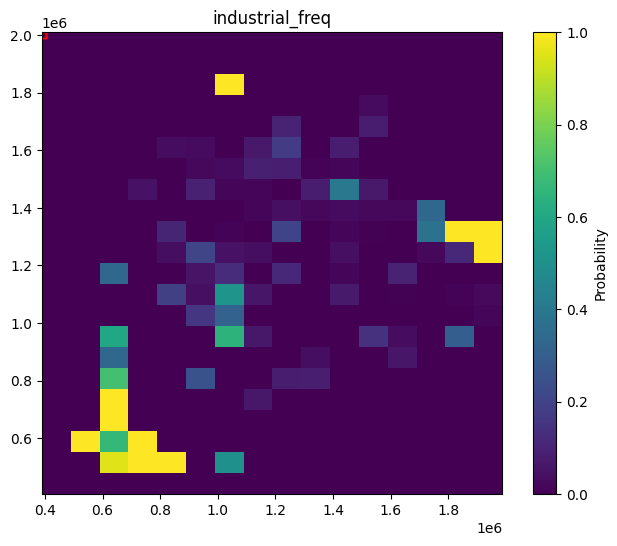

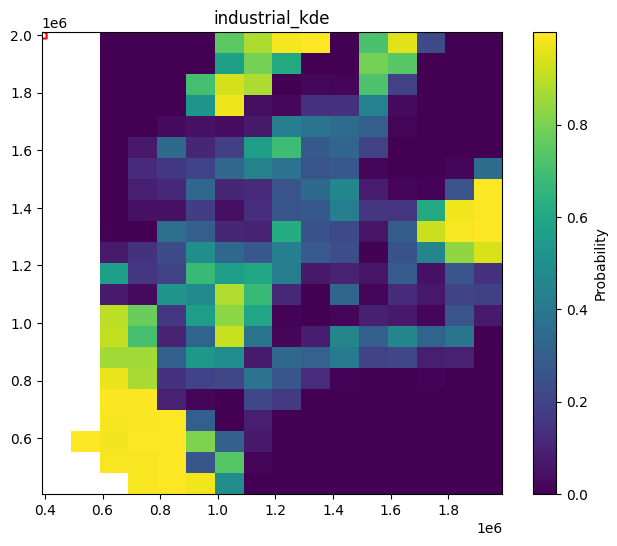

In [30]:
for key, array in probs.items():    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title(key)
    ax.imshow(array, extent=bounds, cmap='viridis')
    
    # Add AOI boundary
    aoi_utm.boundary.plot(ax=ax, color='red', linewidth=1.5)
    
    plt.colorbar(ax.images[0], label='Probability')
    plt.show()

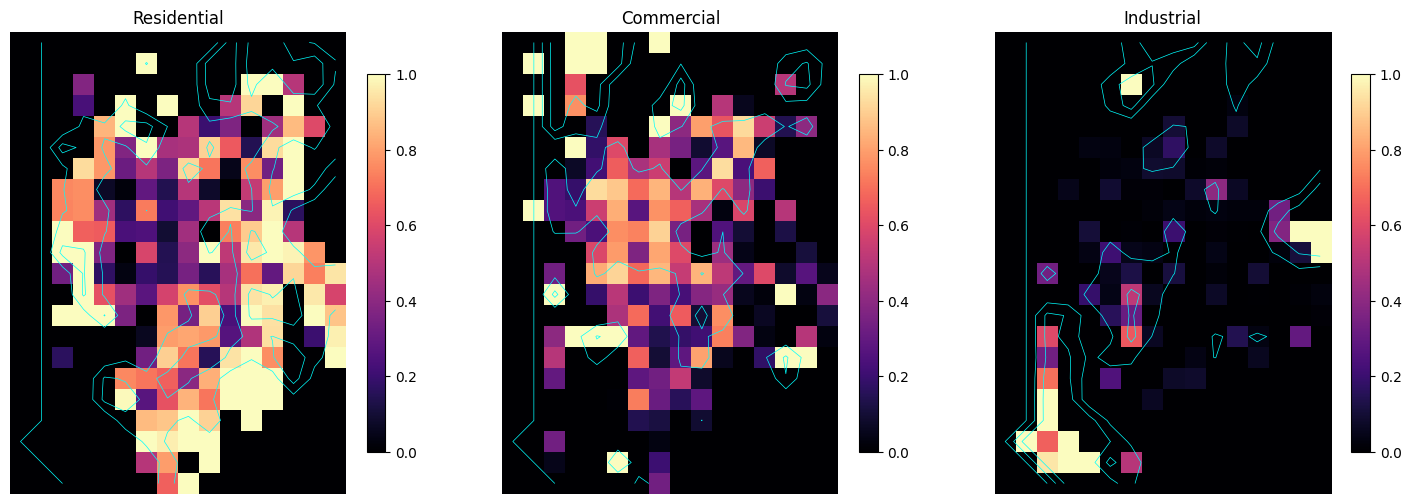

In [31]:
fig = plt.figure(figsize=(18, 6))

land_uses = ['residential', 'commercial', 'industrial']

for idx, land_use in enumerate(land_uses):
    ax = plt.subplot(1, 3, idx + 1)  # Create and store the axis
    
    # Show frequency as heatmap
    ax.imshow(probs[f'{land_use}_freq'], cmap='magma', vmin=0, vmax=1)
    
    # Replace lines 12-14 with:
    kde_for_contour = np.nan_to_num(probs[f'{land_use}_kde'], nan=0.0)
    if kde_for_contour.max() > 0:
        ax.contour(kde_for_contour, 
                levels=2, colors='cyan', linewidths=0.5, alpha=1)
    
    ax.set_title(f'{land_use.capitalize()}')
    plt.colorbar(ax.images[0], ax=ax, fraction=0.046)
    ax.axis('off')

In [32]:
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import from_bounds

# Get transform and CRS
transform = from_bounds(bounds[0], bounds[1], bounds[2], bounds[3], width, height)
crs_utm = builtup.rio.crs
crs_4326 = 'EPSG:4326'

# Save as GeoTIFF in EPSG:4326
for land_use in ['residential', 'commercial', 'industrial']:
    for method in ['freq', 'kde']:
        data = probs[f'{land_use}_{method}']
        
        # Convert to float32 and use -9999 as nodata
        data_float = data.astype(np.float32)
        nodata_val = -9999.0
        data_float = np.where(np.isnan(data_float), nodata_val, data_float)
        
        # Calculate transform for EPSG:4326
        transform_4326, width_4326, height_4326 = calculate_default_transform(
            crs_utm, crs_4326, width, height, *bounds
        )
        
        # Save reprojected TIF with nodata
        tif_path = os.path.join(data_dir, f'{cityname}_{method}_{land_use}.tif')
        with rasterio.open(
            tif_path, 'w',
            driver='GTiff',
            height=height_4326,
            width=width_4326,
            count=1,
            dtype='float32',
            crs=crs_4326,
            transform=transform_4326,
            nodata=nodata_val
        ) as dst:
            reproject(
                source=data_float,
                destination=rasterio.band(dst, 1),
                src_transform=transform,
                src_crs=crs_utm,
                dst_transform=transform_4326,
                dst_crs=crs_4326,
                resampling=Resampling.bilinear,
                src_nodata=nodata_val,
                dst_nodata=nodata_val
            )
        
        print(f"Saved {cityname}_{method}_{land_use}.tif (EPSG:4326)")

# Save OSM as GPKG in EPSG:4326
for land_use, gdf in osm.items():
    if len(gdf) > 0:
        gpkg_path = os.path.join(data_dir, f'{cityname}_osm_{land_use}.gpkg')
        gdf[['geometry']].to_crs('EPSG:4326').to_file(gpkg_path, driver='GPKG')
        print(f"Saved {cityname}_osm_{land_use}.gpkg (EPSG:4326)")

Saved nouakchott_freq_residential.tif (EPSG:4326)
Saved nouakchott_kde_residential.tif (EPSG:4326)
Saved nouakchott_freq_commercial.tif (EPSG:4326)
Saved nouakchott_kde_commercial.tif (EPSG:4326)
Saved nouakchott_freq_industrial.tif (EPSG:4326)
Saved nouakchott_kde_industrial.tif (EPSG:4326)
Saved nouakchott_osm_residential.gpkg (EPSG:4326)
Saved nouakchott_osm_commercial.gpkg (EPSG:4326)
Saved nouakchott_osm_industrial.gpkg (EPSG:4326)


In [33]:
fsdfsadf

NameError: name 'fsdfsadf' is not defined

### RS INPUTS

In [ ]:
s1_tifs = [f for f in t_files if 's1_' in f]
s2_tifs = [f for f in t_files if 's2_' in f]
nl_tifs = [f for f in t_files if 'nightlight_' in f]
tifs = [f for f in files if f.endswith('.tif')]
pop_tifs = [f for f in tifs if 'ghs_pop' in f]

s2 = rxr.open_rasterio(sorted(s2_tifs)[-5], masked=True)
s1 = rxr.open_rasterio(sorted(s1_tifs)[-5], masked=True)

nl = rxr.open_rasterio(sorted(nl_tifs)[-5], masked=True)
ghs_pop = rxr.open_rasterio(sorted(pop_tifs)[-3], masked=True)

ghs_build = ghs_builts[2020]['res'] + ghs_builts[2020]['nres']


In [ ]:
import spyndex

idx = spyndex.computeIndex(
    index = ["NDBI","NDVI", "SAVI"],
    params = {
        "B": s2.sel(band =1),
        "G": s2.sel(band =2),
        "R": s2.sel(band =3),
        "N": s2.sel(band =4),
        "S1":s2.sel(band =5),
        "L": 0.5
    }
)

s2indices = {}

for i in ["NDBI","NDVI", "SAVI"]:
    s2idx = s2.sel(band=1).copy()
    s2idx.values = idx.sel(index = i).values
    s2indices[i] = s2idx

saridx = spyndex.computeIndex(
    index = ["VDDPI","NDPolI", "DPDD", "VHVVR"],
    params = {
        "VV": s2.sel(band =1),
        "VH": s2.sel(band =2),
    }
)

sarindices = {} 
for i in ["VDDPI","NDPolI", "DPDD", "VHVVR"]:
    saridx_raster = s1.sel(band=1).copy()
    saridx_raster.values = saridx.sel(index = i).values
    sarindices[i] = saridx_raster


### ML Modeling

In [ ]:
import xarray as xr
import rioxarray as rxr
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
from rasterio.enums import Resampling

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def train_model(feature_list, use_pca=False, n_components=None):
 
    print(f"Training with features: {feature_list}")
    if use_pca:
        print(f"Using PCA (n_components={n_components if n_components else 'auto'})\n")
    
    # Resample features to 1km
    target_shape_1km = probs['commercial_freq'].shape
    features_1km = {}
    
    for feat in feature_list:
        print(f"  Resampling {feat}...")
        
        if feat == 'ghs_build':
            f = ghs_build.rio.reproject(ghs_build.rio.crs, shape=target_shape_1km, resampling=Resampling.sum)
            features_1km[feat] = f.values
        elif feat == 'nightlight':
            f = nl.rio.reproject(nl.rio.crs, shape=target_shape_1km, resampling=Resampling.average)
            features_1km[feat] = f.values[0] if f.values.ndim == 3 else f.values
        elif feat.startswith('s2_'):
            idx_name = feat.replace('s2_', '')
            f = s2indices[idx_name].rio.reproject(s2indices[idx_name].rio.crs, shape=target_shape_1km, resampling=Resampling.average)
            features_1km[feat] = f.values
        elif feat.startswith('s1_'):
            idx_name = feat.replace('s1_', '')
            f = sarindices[idx_name].rio.reproject(sarindices[idx_name].rio.crs, shape=target_shape_1km, resampling=Resampling.average)
            features_1km[feat] = f.values
    
    # Prepare data
    has_osm = probs['commercial_freq'] < 1.0
    X_list = [features_1km[f][has_osm] for f in feature_list]
    X_train = np.column_stack(X_list)
    valid = ~np.isnan(X_train).any(axis=1)
    X_train = X_train[valid]
    
    # Normalize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)
    
    # PCA
    if use_pca:
        if n_components is None:
            # Auto-select with elbow method
            pca_full = PCA()
            pca_full.fit(X_scaled)
            
            # Elbow: find where cumulative variance > 0.9
            cumvar = np.cumsum(pca_full.explained_variance_ratio_)
            n_components = np.argmax(cumvar > 0.9) + 1
            
            # print(f"\nPCA variance explained:")
            for i in range(len(pca_full.explained_variance_ratio_)):
                print(f"  PC{i+1}: {pca_full.explained_variance_ratio_[i]:.3f} (cumulative: {cumvar[i]:.3f})")
            # print(f"\nElbow method selected {n_components} components (90% variance)\n")
            
            
        
        pca = PCA(n_components=n_components)
        X_final = pca.fit_transform(X_scaled)
        preprocessor = {'scaler': scaler, 'pca': pca}
    else:
        X_final = X_scaled
        preprocessor = {'scaler': scaler}
    
    y_train = {lu: probs[lu][has_osm][valid] for lu in ['residential_freq', 'commercial_freq', 'industrial_freq']}
    
    print(f"Training: {len(X_final)} samples, {X_final.shape[1]} features\n")
    
    # Train with CV
    results = {}
    for land_use in ['residential_freq', 'commercial_freq', 'industrial_freq']:
    
        model = RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            min_samples_split=5,
            random_state=42,
            n_jobs=-1
        )
        
        model.fit(X_final, y_train[land_use])
        train_score = model.score(X_final, y_train[land_use])
        print(f"{land_use}: Training R² = {train_score:.3f}")
        
        # ADD THIS:
        results[land_use] = {
            'model': model,
            'preprocessor': preprocessor,
            'train_score': train_score
        }
            
    return results, feature_list


In [ ]:
# Try with PCA:
results, features = train_model(
    [ 'nightlight',  's2_NDBI',  's2_NDVI' , 's2_SAVI', 's1_VHVVR', 'ghs_build', 's1_DPDD',],
    # [   'ghs_build', 's2_NDBI' , 's1_VHVVR',],

    use_pca=True
)

Training with features: ['nightlight', 's2_NDBI', 's2_NDVI', 's2_SAVI', 's1_VHVVR', 'ghs_build', 's1_DPDD']
Using PCA (n_components=auto)

  Resampling nightlight...
  Resampling s2_NDBI...
  Resampling s2_NDVI...
  Resampling s2_SAVI...
  Resampling s1_VHVVR...
  Resampling ghs_build...
  Resampling s1_DPDD...
  PC1: 0.640 (cumulative: 0.640)
  PC2: 0.149 (cumulative: 0.789)
  PC3: 0.100 (cumulative: 0.889)
  PC4: 0.057 (cumulative: 0.947)
  PC5: 0.035 (cumulative: 0.982)
  PC6: 0.018 (cumulative: 1.000)
  PC7: 0.000 (cumulative: 1.000)
Training: 392 samples, 4 features

residential_freq: Training R² = 0.613
commercial_freq: Training R² = 0.872
industrial_freq: Training R² = 0.718


In [ ]:
def predict_100m(results, feature_list):
    """Predict land use probabilities at 100m"""
    
    print("Predicting at 100m resolution...\n")
    
    # Target shape
    target_shape_100m = ghs_build.shape
    print(f"Target shape: {target_shape_100m}")
    
    # Resample features to 100m
    features_100m = {}
    
    for feat in feature_list:
        print(f"  Resampling {feat}...")
        
        if feat == 'ghs_build':
            features_100m[feat] = ghs_build.values
        elif feat == 'nightlight':
            f = nl.rio.reproject(nl.rio.crs, shape=target_shape_100m, resampling=Resampling.average)
            features_100m[feat] = f.values[0] if f.values.ndim == 3 else f.values
        elif feat.startswith('s2_'):
            idx_name = feat.replace('s2_', '')
            f = s2indices[idx_name].rio.reproject(s2indices[idx_name].rio.crs, shape=target_shape_100m, resampling=Resampling.average)
            features_100m[feat] = f.values
        elif feat.startswith('s1_'):
            idx_name = feat.replace('s1_', '')
            f = sarindices[idx_name].rio.reproject(sarindices[idx_name].rio.crs, shape=target_shape_100m, resampling=Resampling.average)
            features_100m[feat] = f.values
    
    # Stack and preprocess
    X_pred_list = [features_100m[f].ravel() for f in feature_list]
    X_pred = np.column_stack(X_pred_list)
    valid_mask = ~np.isnan(X_pred).any(axis=1)
    
    # Apply same preprocessing as training
    preprocessor = results['residential_freq']['preprocessor']
    X_pred_scaled = preprocessor['scaler'].transform(X_pred[valid_mask])
    if 'pca' in preprocessor:
        X_pred_final = preprocessor['pca'].transform(X_pred_scaled)
    else:
        X_pred_final = X_pred_scaled
    
    print(f"\nPredicting {valid_mask.sum()} valid pixels...")
    
    # Predict each land use
    probs_100m = {}
    for land_use in ['residential_freq', 'commercial_freq', 'industrial_freq']:
        print(f"  {land_use}...")
        pred_flat = np.full(len(valid_mask), np.nan)
        pred_flat[valid_mask] = results[land_use]['model'].predict(X_pred_final)
        pred_flat = np.clip(pred_flat, 0, 1)
        probs_100m[land_use] = pred_flat.reshape(target_shape_100m)
    
    # Normalize
    total = probs_100m['residential_freq'] + probs_100m['commercial_freq'] + probs_100m['industrial_freq']
    total = np.where(total > 0, total, 1.0)
    
    for land_use in probs_100m:
        probs_100m[land_use] = probs_100m[land_use] / total
        probs_100m[land_use] = np.where(ghs_build.values > 500, probs_100m[land_use], np.nan)
    
    return probs_100m

Predicting at 100m resolution...

Target shape: (1124, 1557)
  Resampling nightlight...
  Resampling s2_NDBI...
  Resampling s2_NDVI...
  Resampling s2_SAVI...
  Resampling s1_VHVVR...
  Resampling ghs_build...
  Resampling s1_DPDD...

Predicting 631878 valid pixels...
  residential_freq...
  commercial_freq...
  industrial_freq...


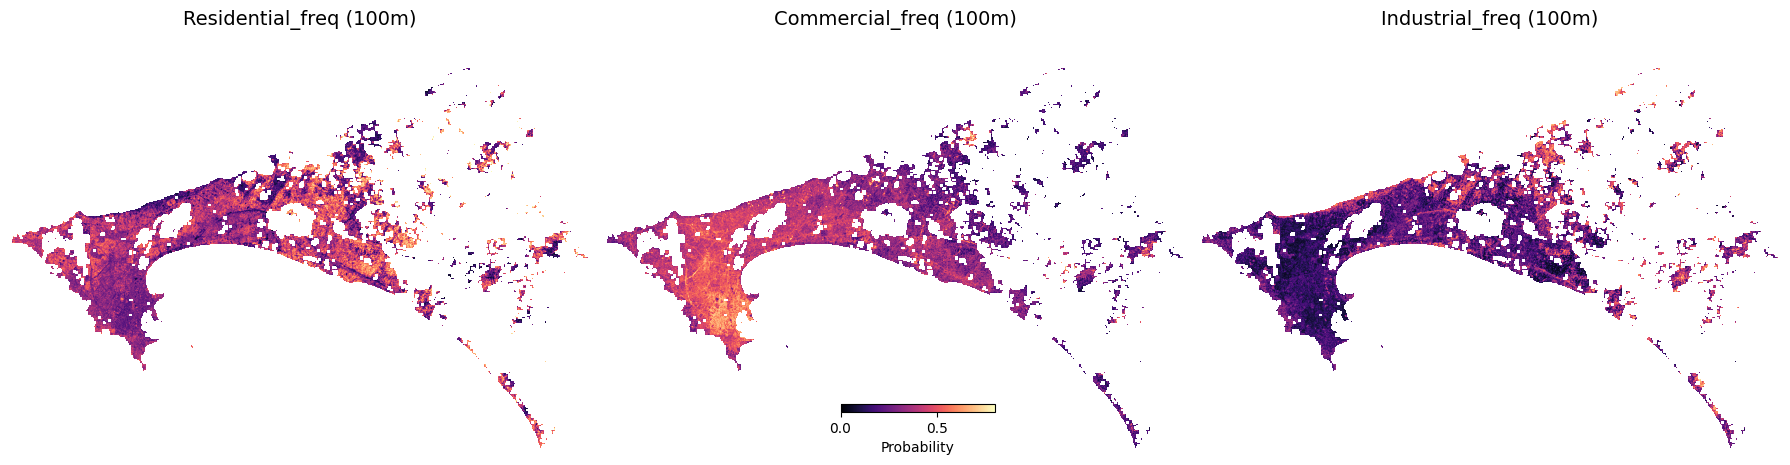

In [ ]:
# Predict
probs_100m = predict_100m(results, features)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (land_use, prob) in enumerate(probs_100m.items()):
    axes[idx].imshow(prob, cmap='magma', vmin=0, vmax=0.8)
    axes[idx].set_title(f'{land_use.capitalize()} (100m)', fontsize=14)
    axes[idx].axis('off')
plt.colorbar(axes[0].images[0], ax=axes, orientation='horizontal', 
             fraction=0.02, pad=0.04, label='Probability')
plt.tight_layout()
plt.show()